# (01) **Load SemanticKITTI Data**

This notebook verifies that the SemanticKITTI subset is correctly placed and can be loaded for the reflect-aug-seg project.

Goals:
- locate the dataset.
- load one LiDAR frame (`.bin`).
- load the corresponding semantic labels (`.label`).
- verify shapes and contents.
- make a quick sanity-check visualization.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Define dataset paths

We point the notebook to SemanticKITTI sequence `00` and verify that the expected folders exist:

- `velodyne/` for LiDAR point clouds.
- `labels/` for semantic labels.

This ensures the dataset was copied into the repository correctly before loading any frames.

In [2]:
DATA_DIR = "../data/semantickitti_subset/dataset/sequences/00"
VELODYNE_DIR = os.path.join(DATA_DIR, "velodyne")
LABEL_DIR = os.path.join(DATA_DIR, "labels")

print("DATA_DIR      :", DATA_DIR)
print("VELODYNE_DIR  :", VELODYNE_DIR)
print("LABEL_DIR     :", LABEL_DIR)

print("\nExists check:")
print("DATA_DIR exists     :", os.path.exists(DATA_DIR))
print("VELODYNE_DIR exists :", os.path.exists(VELODYNE_DIR))
print("LABEL_DIR exists    :", os.path.exists(LABEL_DIR))

DATA_DIR      : ../data/semantickitti_subset/dataset/sequences/00
VELODYNE_DIR  : ../data/semantickitti_subset/dataset/sequences/00/velodyne
LABEL_DIR     : ../data/semantickitti_subset/dataset/sequences/00/labels

Exists check:
DATA_DIR exists     : True
VELODYNE_DIR exists : True
LABEL_DIR exists    : True


## Step 2: Inspect available frames

Before loading any data, we list a few files from the `velodyne/` and `labels/` folders.

This helps verify:

- frames are present.
- naming is consistent.
- point clouds and labels can be matched by frame ID.

In [3]:
velodyne_files = sorted([f for f in os.listdir(VELODYNE_DIR) if f.endswith(".bin")])
label_files = sorted([f for f in os.listdir(LABEL_DIR) if f.endswith(".label")])

print("Number of .bin files   :", len(velodyne_files))
print("Number of .label files :", len(label_files))

print("\nFirst 5 velodyne files:")
print(velodyne_files[:5])

print("\nFirst 5 label files:")
print(label_files[:5])

print("\nLast 5 velodyne files:")
print(velodyne_files[-5:])

print("\nLast 5 label files:")
print(label_files[-5:])

Number of .bin files   : 4541
Number of .label files : 4541

First 5 velodyne files:
['000000.bin', '000001.bin', '000002.bin', '000003.bin', '000004.bin']

First 5 label files:
['000000.label', '000001.label', '000002.label', '000003.label', '000004.label']

Last 5 velodyne files:
['004536.bin', '004537.bin', '004538.bin', '004539.bin', '004540.bin']

Last 5 label files:
['004536.label', '004537.label', '004538.label', '004539.label', '004540.label']


## Step 3: Load a LiDAR frame

We load a single frame (`000000.bin`) from the dataset.

Each point should have 4 values:

- x, y, z → spatial coordinates.
- intensity → returned signal strength.

We verify the shape and inspect a few sample points.

In [4]:
frame_id = "000000"

bin_path = os.path.join(VELODYNE_DIR, f"{frame_id}.bin")

points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)

print("Loaded frame:", frame_id)
print("Point cloud shape:", points.shape)

print("\nFirst 5 points:")
print(points[:5])

Loaded frame: 000000
Point cloud shape: (124668, 4)

First 5 points:
[[5.2897942e+01 2.2989739e-02 1.9979945e+00 7.9999998e-02]
 [5.3750526e+01 1.9291429e-01 2.0269539e+00 0.0000000e+00]
 [5.3803116e+01 3.6183926e-01 2.0289137e+00 0.0000000e+00]
 [7.2600662e+01 1.2964664e+00 2.6647117e+00 0.0000000e+00]
 [7.2118256e+01 1.5133761e+00 2.6476634e+00 0.0000000e+00]]


## Step 4: Load the matching semantic labels

Each LiDAR frame has a corresponding `.label` file.

SemanticKITTI stores labels as packed 32-bit integers:
    
- lower 16 bits → semantic class ID.
- upper 16 bits → instance ID.

For this project, we first extract the semantic class labels and verify that the number of labels matches the number of LiDAR points.

In [5]:
label_path = os.path.join(LABEL_DIR, f"{frame_id}.label")

raw_labels = np.fromfile(label_path, dtype=np.uint32)
semantic_labels = raw_labels & 0xFFFF

print("Loaded label file for frame:", frame_id)
print("Raw labels shape:", raw_labels.shape)
print("Semantic labels shape:", semantic_labels.shape)

print("\nFirst 10 raw labels:")
print(raw_labels[:10])

print("\nFirst 10 semantic labels:")
print(semantic_labels[:10])

print("\nPoint-label count match:", points.shape[0] == semantic_labels.shape[0])

Loaded label file for frame: 000000
Raw labels shape: (124668,)
Semantic labels shape: (124668,)

First 10 raw labels:
[0 0 0 0 0 0 0 0 0 0]

First 10 semantic labels:
[0 0 0 0 0 0 0 0 0 0]

Point-label count match: True


## Step 5: Inspect semantic class distribution

We analyze which semantic classes are present in this frame and how many points belong to each class.

This helps us understand:

- whether meaningful objects exist in the frame.
- class imbalance (very important later).

In [6]:
unique_classes, counts = np.unique(semantic_labels, return_counts=True)

print("Number of unique classes in this frame:", len(unique_classes))

print("\nClass distribution (class_id : count):")
for cls, cnt in zip(unique_classes, counts):
    print(f"{cls:>3} : {cnt}")

Number of unique classes in this frame: 17

Class distribution (class_id : count):
  0 : 2184
  1 : 4
 10 : 4234
 40 : 34228
 44 : 3268
 48 : 26360
 50 : 18268
 51 : 370
 52 : 1471
 60 : 1053
 70 : 27123
 71 : 1192
 72 : 2964
 80 : 532
 81 : 102
 99 : 1227
255 : 88


## Step 6: Top-down visualization (semantic labels)

We visualize the LiDAR point cloud in the XY plane (top-down view),
coloring each point by its semantic class.

This gives a quick spatial understanding of the scene structure.

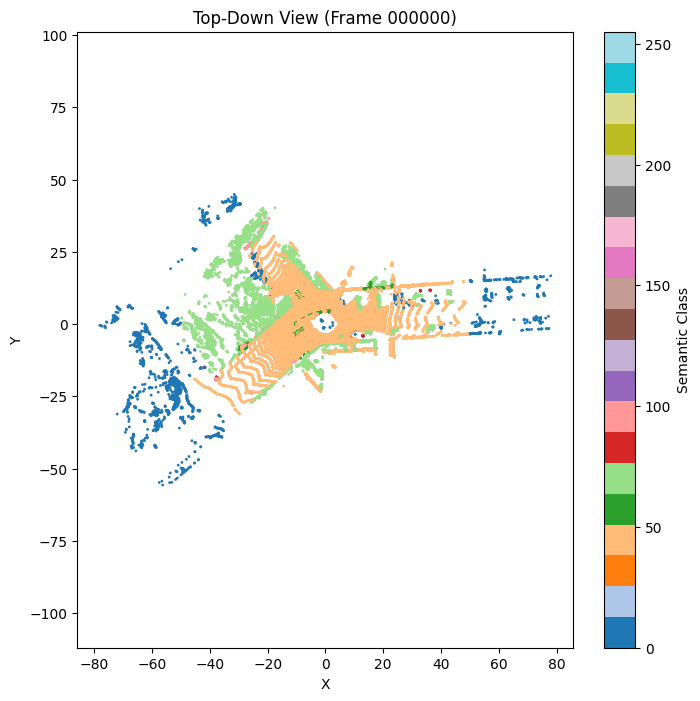

In [7]:
plt.figure(figsize=(8, 8))

scatter = plt.scatter(
    points[:, 0],  # x
    points[:, 1],  # y
    c=semantic_labels,
    s=1,
    cmap="tab20"
)

plt.colorbar(scatter, label="Semantic Class")
plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Top-Down View (Frame {frame_id})")

plt.axis("equal")
plt.show()

## Summary

- Successfully loaded SemanticKITTI frame.
- Verified point-label alignment.
- Observed multiple semantic classes.
- Visualized scene structure.

This confirms the dataset is ready for feature engineering and analysis in the next notebook.